В цьому домашньому завданні кожне завдання оцінюється по 10 балів.

 **Завдання 1.** Після перегляду лекцій про поняття функії, вступ до лінійної алгебри і мат. формулювання лін. регресії знайдіть найкращу лінію для прогнозу `charges` за `age` **для некурців** (датафрейм `non_smoker_df`) з допомогою

1. Методу МНК (з використанням тільки `numpy`, без `scikit learn`)

2. Full-Batch градієнтного спуску з `numpy` . Протестуйте 3 різних learning rate і зробіть висновок, який є найкращим виходячи з практик для цього, наведених в лекції. Зверніть увагу, що на вхід треба набір даних дворозміний, для цього можливо треба буде трансформувати Ваші дані X в формат, як був в лекції "Математичне формулювання лінійної регресії". Також, градієнтний спуск в нашому випадку може розходитись з навчальним рейтом 0.1, бо цей рейт в цій задачі завеликий. Спробуйте нижчі рейти.
3. З `scikit-learn.LinearRegression`. Тут зверніть увагу, що вхід `X` має бути двовимірним масивом, тому нам потрібно передати dataframe, а не окрему колонку. Якщо у Вас X - колонка (а у Вас так мало б бути), то можна скористатись `X.to_frame()` щоб конвертувати колонку в датафрейм.

Для кожного методу
- знайдіть і виведіть коефіцієнти моделі
- обчисліть прогнози моделі і збережіть в окрему змінну
- порахуйте точність прогнозу RMSE  

Для градієнтного спуску виведіть графік помилки в залежності від ітерації.

А також побудуйте на одному графіку дані `age` проти `charges` в вигляді діаграми розсіювання і всі три лінії регресії, знайдені кожним з методів (для град. спуску оберіть варіант з тим learning rate, який виявився найкращим).

Зробіть висновки, чи відрізняються результати моделей?
Чи є знайдены параметри моделы близькими до ваших найкращих припущень?

In [54]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [26]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [27]:
medical_df = pd.read_csv('/content/drive/MyDrive/ML1/data/medical-charges.csv')
non_smoker_df = medical_df[medical_df.smoker == 'no']

In [28]:
X = non_smoker_df[['age']].values
y = non_smoker_df['charges'].values

# 1.МНК
def normal_equations(X, y):
    """Computes the closed-form solution to linear regression"""
    theta = np.linalg.inv(X.T.dot(X)).dot(X.T).dot(y)
    return theta

# Додаємо колонку одиничок аби задати bias терм (константу в моделі регресії)
X_with_intercept = np.c_[np.ones((X.shape[0], 1)), X]
X[:3], X_with_intercept[:3]

(array([[18],
        [28],
        [33]]),
 array([[ 1., 18.],
        [ 1., 28.],
        [ 1., 33.]]))

In [29]:
MNK_coefs = normal_equations(X_with_intercept, y)
print(f"МНК коефіцієнти array: {MNK_coefs}")
print(f"МНК коефіцієнти: b={MNK_coefs[0]:.4f}, w={MNK_coefs[1]:.4f}")

predictions_MNK = np.dot(X_with_intercept, MNK_coefs)
rmse_mnk = np.sqrt(np.mean((y - predictions_MNK)**2))
print(f"МНК RMSE: {rmse_mnk:.2f}")

МНК коефіцієнти array: [-2091.42055657   267.24891283]
МНК коефіцієнти: b=-2091.4206, w=267.2489
МНК RMSE: 4662.51


In [38]:
#1.2.Full-Batch градієнтного спуску
def full_batch_gradient_descent(X, y, lr=0.1, epochs=1000):
    m, b = 0.0, 0.0  # початкові параметри
    n = len(y)
    errors = []

    for _ in range(epochs):
        y_pred = m * X[:, 0] + b
        error = y_pred - y
        errors.append(np.sqrt(np.mean(error**2)))  # RMSE
        m_gradient = (2/n) * np.dot(error, X[:, 0])
        b_gradient = (2/n) * np.sum(error)
        m = m - lr * m_gradient
        b = b - lr * b_gradient
    return m, b, errors

lr=1e-06: w=213.4576, b=4.3312, RMSE=4723.70


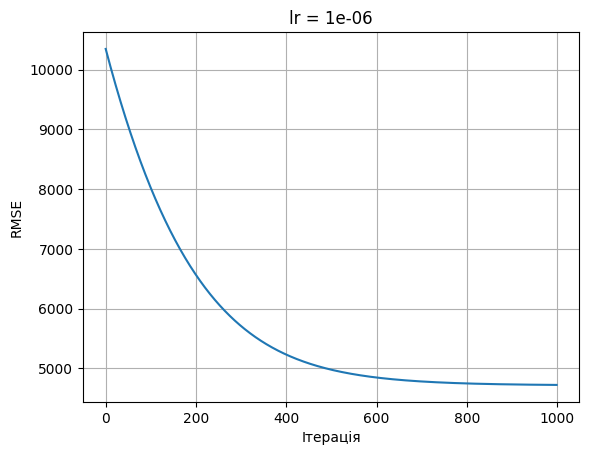

In [52]:
# test 3 learning rate
lr = 0.000001
m_gd3, b_gd3, errors3 = full_batch_gradient_descent(X, y, lr, epochs=1000)
print(f"lr={lr}: w={m_gd3:.4f}, b={b_gd3:.4f}, RMSE={errors3[-1]:.2f}")
plt.plot(errors3)
plt.title(f'lr = {lr}')
plt.xlabel('Ітерація')
plt.ylabel('RMSE')
plt.grid(True)
plt.show()

lr=0.005: w=nan, b=nan, RMSE=nan


/tmp/ipykernel_6285/2217704126.py:10: RuntimeWarning: overflow encountered in square
  errors.append(np.sqrt(np.mean(error**2)))  # RMSE
/tmp/ipykernel_6285/2217704126.py:13: RuntimeWarning: invalid value encountered in scalar subtract
  m = m - lr * m_gradient


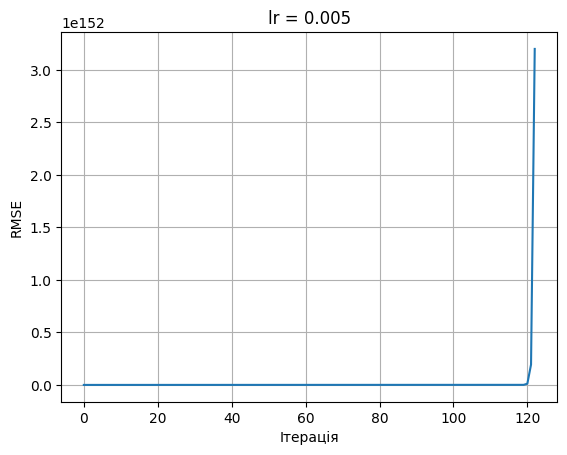

In [48]:
# lr = 0.005
lr2 = 0.005
m_gd2, b_gd2, errors2 = full_batch_gradient_descent(X, y, lr2, epochs=1000)
print(f"lr={lr2}: w={m_gd2:.4f}, b={b_gd2:.4f}, RMSE={errors2[-1]:.2f}")
plt.plot(errors2)
plt.title(f'lr = {lr2}')
plt.xlabel('Ітерація')
plt.ylabel('RMSE')
plt.grid(True)
plt.show()

lr=0.0001: w=221.1046, b=-41.9813, RMSE=4713.25


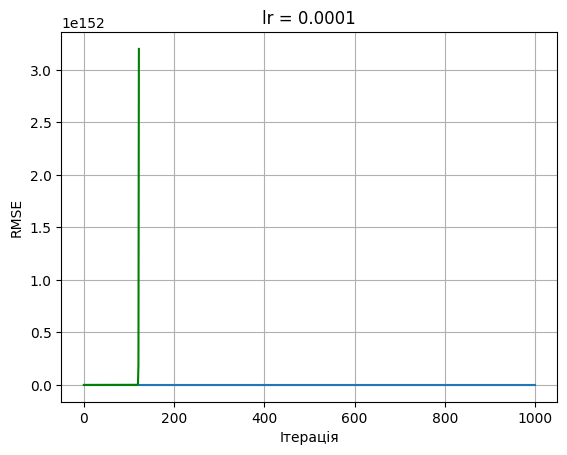

In [50]:
# lr = 0.0001
lr3 = 0.0001
m_gd1, b_gd1, errors1 = full_batch_gradient_descent(X, y, lr3, epochs=1000)
print(f"lr={lr3}: w={m_gd1:.4f}, b={b_gd1:.4f}, RMSE={errors1[-1]:.2f}")
plt.plot(errors1)
plt.title(f'lr = {lr3}')
plt.plot(errors2, color='green')
plt.xlabel('Ітерація')
plt.ylabel('RMSE')
plt.grid(True)
plt.show()

In [53]:
# Найкращий lr — прогнози для градієнтного спуску
predictions_GD = m_gd1 * X[:, 0] + b_gd1
rmse_gd = errors1[-1]
print(f"Градієнтний спуск: w={m_gd1:.4f}, b={b_gd1:.4f}, RMSE={rmse_gd:.2f}")

Градієнтний спуск: w=221.1046, b=-41.9813, RMSE=4713.25


In [56]:
# 1.3. Sklearn
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error

X_df = non_smoker_df[['age']]
model = LinearRegression()
model.fit(X_df, y)

predictions_sklearn = model.predict(X_df)
rmse_sklearn = np.sqrt(np.mean((y - predictions_sklearn)**2))
print(f"Sklearn: w={model.coef_[0]:.4f}, b={model.intercept_:.4f}, RMSE={rmse_sklearn:.4f}")

Sklearn: w=267.2489, b=-2091.4206, RMSE=4662.5058


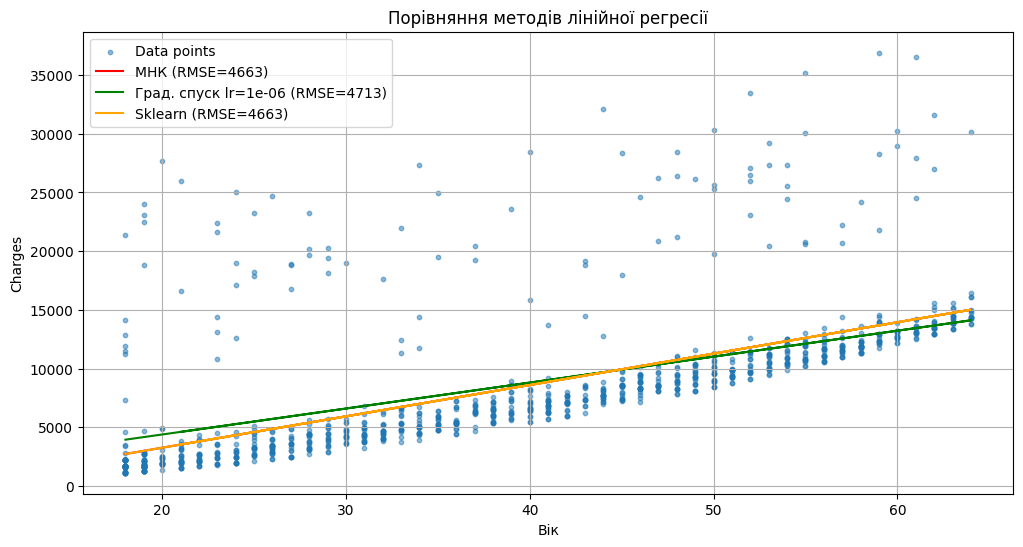

In [59]:
# Фінальний графік — всі три методи
plt.figure(figsize=(12, 6))
plt.scatter(X[:, 0], y, alpha=0.5, s=10, label='Data points')
plt.plot(X[:, 0], predictions_MNK, color='red', label=f'МНК (RMSE={rmse_mnk:.0f})')
plt.plot(X[:, 0], predictions_GD, color='green', label=f'Град. спуск lr={lr} (RMSE={rmse_gd:.0f})')
plt.plot(X[:, 0], predictions_sklearn, color='orange', label=f'Sklearn (RMSE={rmse_sklearn:.0f})')
plt.xlabel('Вік')
plt.ylabel('Charges')
plt.title('Порівняння методів лінійної регресії')
plt.legend()
plt.grid(True)
plt.show()

** Висновки:**

Коефіцієнти:

1/ МНК: w=267, b=-2091

2/ Sklearn: w=267, b=-2091 (1 & 2 схожі)

3/ Град. спуск lr=1e-06: w=213, b=4  (близько але не точно)

RMSE:
МНК і Sklearn дають однаковий результат
Градієнтний спуск трохи гірший

Порівняння з ручними параметрами (ДЗ попереднє):
Наш найкращий: w=220, b=0 → RMSE 4715 (там був зроблений градієнтний спуск навпіл автоматизований)
МНК знайшов: w=267, b=-2091 → RMSE 4700
Алгоритм знайшов кращі параметри ніж ми вручну.

 **Завдання 2.** Навчіть модель лінійної регресії з допомогою sklearn оцінювати розмір медичних збори для **курців** за їх віком.
Виведіть
- точність моделі
-  коефіцієнти
-  візуалізуйте модель у вигляді лінії на графіку розсіювання `age` проти `charges`

і зробіть висновки, чи це хороша модель, чи ви б її використовували в компанії?

In [71]:
# курці new dataset
smoker_df = medical_df[medical_df.smoker == 'yes']

inputs = smoker_df[['age']]
targets = smoker_df['charges']

RMSE: 10711.00

Коефіцієнти:
  w (age): 305.2376
  b (intercept): 20294.1281


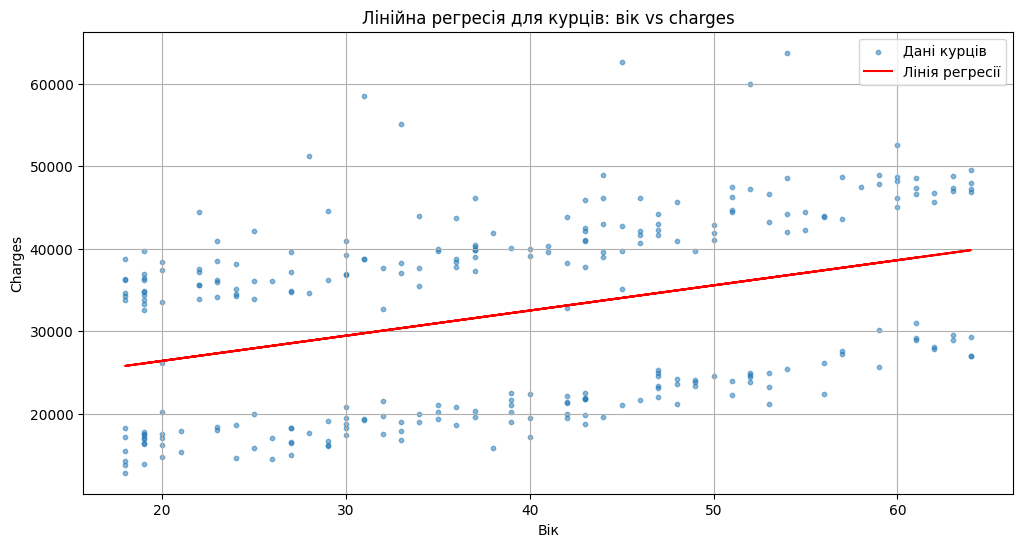

In [72]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error

def train_model_show_rmse(inputs, targets):
    model = LinearRegression().fit(inputs, targets)
    predictions = model.predict(inputs)
    loss = np.sqrt(mean_squared_error(targets, predictions))  # без squared
    print(f'RMSE: {loss:.2f}')
    return model, predictions

# Навчання моделі
model_smoker, predictions_smoker = train_model_show_rmse(inputs, targets)

print(f"\nКоефіцієнти:")
print(f"  w (age): {model_smoker.coef_[0]:.4f}")
print(f"  b (intercept): {model_smoker.intercept_:.4f}")

# Графік age vs charges
plt.figure(figsize=(12, 6))
plt.scatter(smoker_df['age'], targets, alpha=0.5, s=10, label='Дані курців')
plt.plot(smoker_df['age'], predictions_smoker, color='red', label=f'Лінія регресії')
plt.xlabel('Вік')
plt.ylabel('Charges')
plt.title('Лінійна регресія для курців: вік vs charges')
plt.legend()
plt.grid(True)
plt.show()

In [77]:
print(f"Середні charges курців: {targets.mean():.2f}")

from sklearn.metrics import r2_score

r2 = r2_score(targets, predictions_smoker)
print(f"R**2: {r2:.4f}")

Середні charges курців: 32050.23
R**2: 0.1356


**Висновок:**
похибка в 10711 - це майже третина від середнього значення charges, дуже багато.
На графіку залишається два видимих крастера і для них одної лінії недостатньо, треба в ідеалі поділити і побудувати дві окремі моделі.

Для компанії я б цю модель не використовувала.

R**2 = 0.1356 означає що модель пояснює лише 14% charges — це дуже слабкий результат.